# PART9_F2_Prediction

To validate suggested genomic breeding plan, F2 lines derived from selected RILs were measured phenotypes & check effect of beneficial genomic regions

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

from sklearn.linear_model import ElasticNet
from modules.training_module import train_Enet
from modules.make_data_for_prediction import make_data
from modules.make_Haplotype_block import make_Haplotype_block_other_pop

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
traits = ["GN_mean", "PN_mean", "Area.size.AS..mm2."]
CV = 5

## make haplotype blocks of F2 genotypes for prediction

In [ ]:
other_genotype = "../data/genotype_data/F2_genotype.txt"
NAM_HB_genotype = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
family_list = "../data/family_list.csv"
F2_HB_genotype = make_Haplotype_block_other_pop(other_genotype, NAM_HB_genotype, family_list)

In [3]:
## imputed fixed genotypes
Haplotype_block = pd.read_csv(NAM_HB_genotype)
F2_HB_genotype.loc[(Haplotype_block["N01_162"] == 2) & (Haplotype_block["N08_011"] == 2),
                   (F2_HB_genotype.columns.str.contains("GP_B"))|
                   (F2_HB_genotype.columns.str.contains("N01"))|
                   (F2_HB_genotype.columns.str.contains("N08"))] = 2
F2_HB_genotype.loc[(Haplotype_block["N01_162"] == 0) & (Haplotype_block["N08_011"] == 0),
                   (F2_HB_genotype.columns.str.contains("GP_B"))|
                   (F2_HB_genotype.columns.str.contains("N01_162"))|
                   (F2_HB_genotype.columns.str.contains("N08_011"))] = 0
F2_HB_genotype.loc[(Haplotype_block["N17_071"] == 0) & (Haplotype_block["N08_011"] == 0),
                   (F2_HB_genotype.columns.str.contains("GP_A"))|
                   (F2_HB_genotype.columns.str.contains("N17_071"))|
                   (F2_HB_genotype.columns.str.contains("N08_011"))] = 0
F2_HB_genotype.loc[(Haplotype_block["N17_071"] == 2) & (Haplotype_block["N08_011"] == 2),
                   (F2_HB_genotype.columns.str.contains("GP_A"))|
                   (F2_HB_genotype.columns.str.contains("N17"))|
                   (F2_HB_genotype.columns.str.contains("N08"))] = 2
F2_HB_genotype.to_csv("../data/PART9_F2_Prediction/Haplotype_F2_LD90.csv", index=None)

# Prediction

In [18]:
# make genotype dataset for prediction
F2_HB_genotype = pd.read_csv("../data/PART9_F2_Prediction/Haplotype_F2_LD90.csv")
F2_HB_genotype["hash"] = F2_HB_genotype["chr"] + "_" + F2_HB_genotype["pos"]
NAM_HBs = pd.read_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv")
NAM_HBs["hash"] = NAM_HBs["chr"] + "_" + NAM_HBs["pos"]
F2_HB_genotype = F2_HB_genotype[F2_HB_genotype["hash"].isin(NAM_HBs["hash"])].reset_index(drop=True).iloc[:, :-1]

# add genotypes of parent & Hitomebore
F2_HB_genotype_pred = pd.concat([F2_HB_genotype, NAM_HBs.loc[:, ["N01_162", "N08_011", "N17_071"]]], axis=1)
F2_HB_genotype_pred["Hitomebore"] = 0

# Convert genotype for prediction
F2_HB_genotype_pred = F2_HB_genotype_pred.iloc[:, 3:].T.fillna(0)

In [23]:
# make model & predict phenotype values
predicted_data = []
for trait_name in traits:
    print(trait_name)
    genotype_path = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    F2_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_Select_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(0)
        y_train = tmp_train_data[1]
        
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        
        # predicted values of test phenotype
        F2_pred = clf.predict(F2_HB_genotype_pred)
        F2_preds.append(F2_pred)
    
    # average predicted values from CV1-5
    predicted_data.append(np.mean(F2_preds, axis=0))

# make dataframe of results
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = traits
predicted_data.columns = F2_HB_genotype_pred.index.values
predicted_data = predicted_data.T
predicted_data

GN_mean
PN_mean
Area.size.AS..mm2.


,GN_pred,PN_pred,Area.size.AS..mm2._pred
GP_A_06_S28,129.488676,17.322657,17.198269
GP_A_08_S29,178.908841,17.198106,15.966148
GP_A_09_S30,142.006386,15.542169,18.183032
GP_A_10_S31,92.427482,18.685327,16.125213
GP_A_13_S32,149.313839,17.665429,16.339968
GP_A_28_S36,141.521245,17.310895,17.031338
GP_A_29_S37,153.791894,16.617237,17.420332
GP_A_32_S38,155.369420,16.223167,17.969155
GP_A_34_S40,151.511320,17.354658,17.636558
GP_A_35_S41,141.127075,16.968776,16.954895


0.8471818218630975


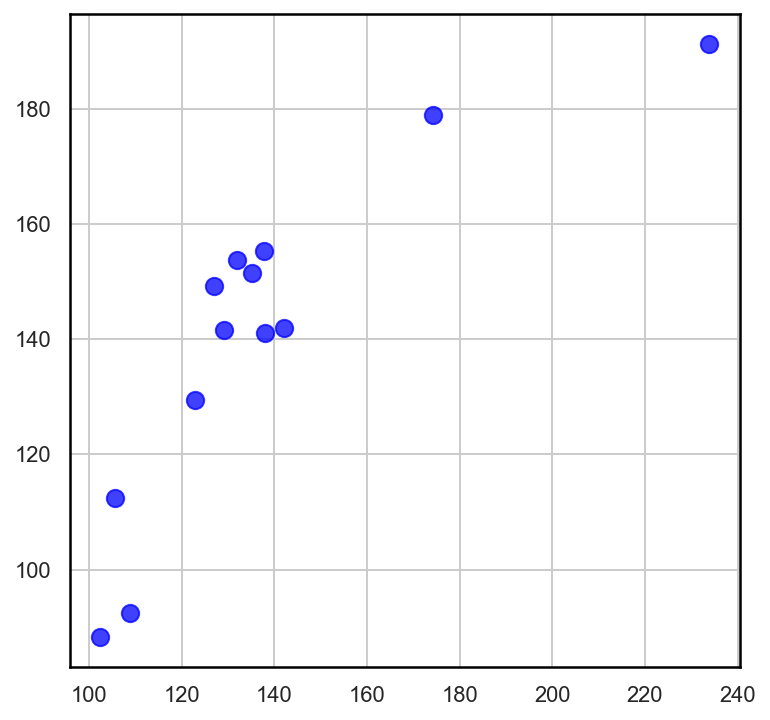

0.6846608604621423


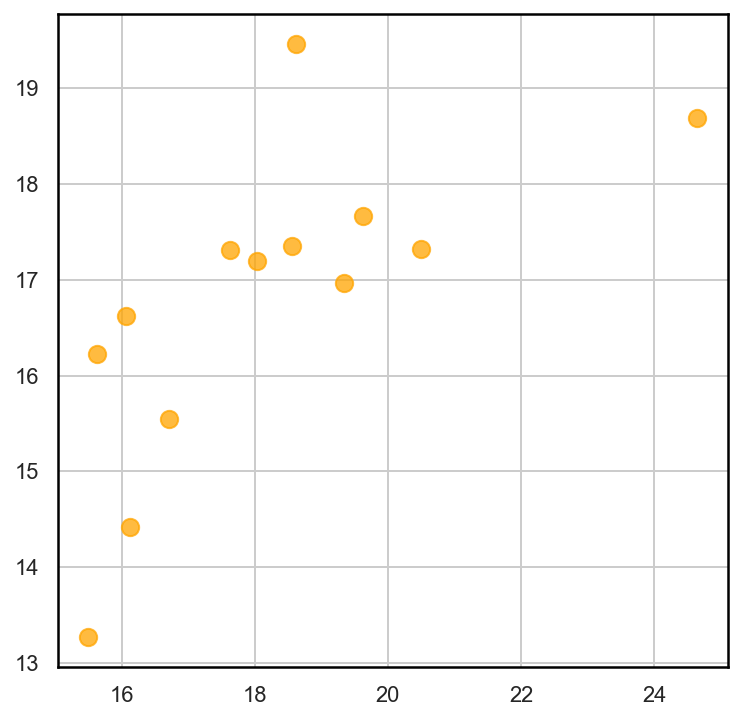

0.653441728748068


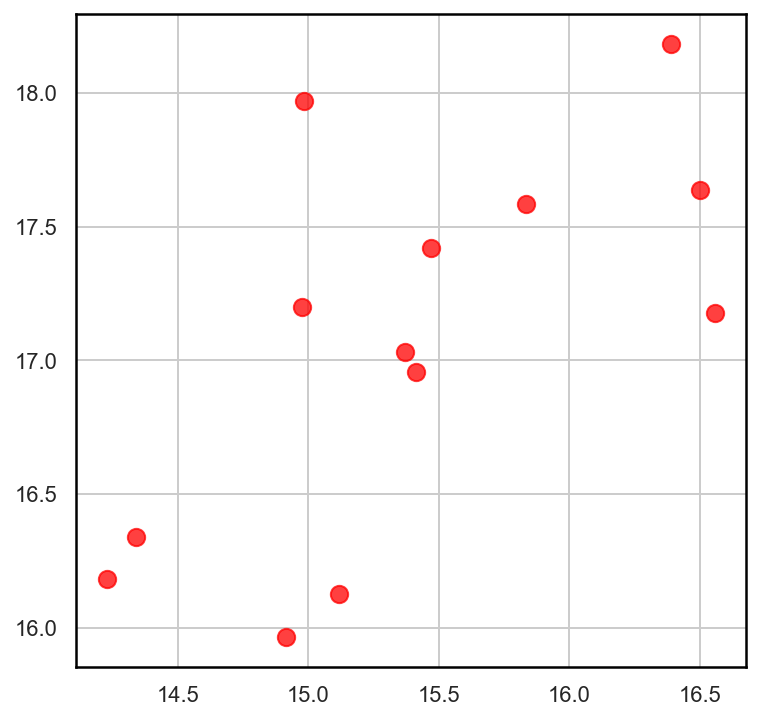

In [53]:
# compare observed and predicted phenotypic values of F2 lines from N17_071 x N08_011
N17_071_x_N08_011 = pd.read_csv("../data/PART9_F2_Prediction/N17_071_x_N08_011_F3_mean_phenotypes.csv", index_col=0)

colors = ["blue", "orange", "red"]
for i, trait in enumerate(["GN", "PN", "Area.size.AS..mm2."]):
    GN_pred = predicted_data.loc[N17_071_x_N08_011.index, f"{trait}_pred"]
    GN_obs = N17_071_x_N08_011.loc[:, f"{trait}_mean"]
    print(np.corrcoef([GN_pred, GN_obs])[0,1])
    
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x=GN_obs, y=GN_pred, s=75, color=colors[i], linewidth=1, alpha=0.75)
    for sp in ["top", "left", "right", "bottom"]:
        ax.spines[sp].set_color('black')
    plt.show()

0.9583737022278658


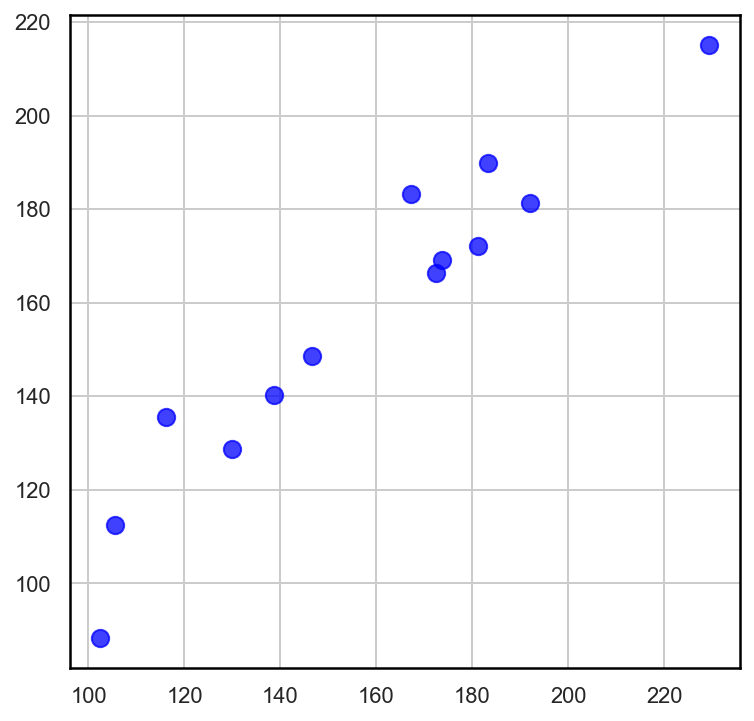

0.793637232020834


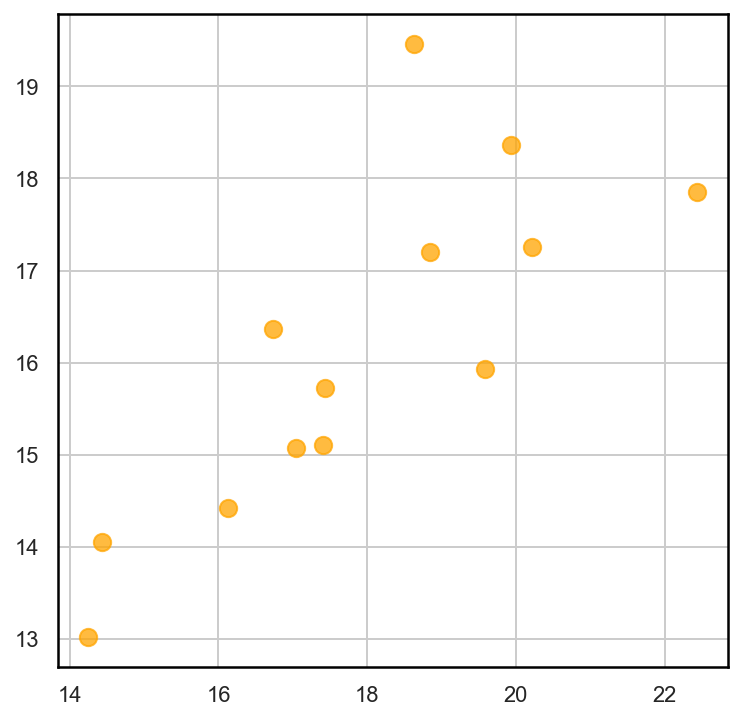

0.6428550223380661


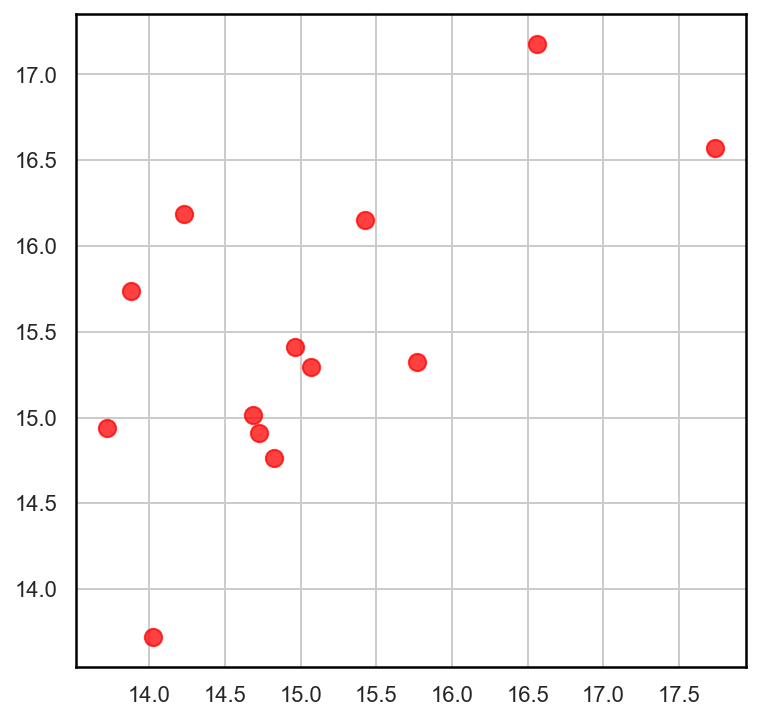

In [50]:
# compare observed and predicted phenotypic values of F2 lines from N01_162 x N08_011
N01_162_x_N08_011 = pd.read_csv("../data/PART9_F2_Prediction/N01_162_x_N08_011_F3_mean_phenotypes.csv", index_col=0)

colors = ["blue", "orange", "red"]
for i, trait in enumerate(["GN", "PN", "Area.size.AS..mm2."]):
    GN_pred = predicted_data.loc[N01_162_x_N08_011.index, f"{trait}_pred"]
    GN_obs = N01_162_x_N08_011.loc[:, f"{trait}_mean"]
    print(np.corrcoef([GN_pred, GN_obs])[0,1])
    
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x=GN_obs, y=GN_pred, s=75, color=colors[i], linewidth=1, alpha=0.75)
    for sp in ["top", "left", "right", "bottom"]:
        ax.spines[sp].set_color('black')
    plt.show()